In [9]:
import py4hw


class FullAdder(py4hw.Logic):
    def __init__(self, parent, name, x, y, ci, s, co):
        super().__init__(parent, name)
        
        x = self.addIn('x', x)
        y = self.addIn('y', y)
        ci = self.addIn('ci', ci)
        s = self.addOut('s', s)
        co = self.addOut('co', co)
        
        w1 = self.wire('w1',1)
        w2 = self.wire('w2',1)
        w3 = self.wire('w3',1)
        
        py4hw.Xor2(self, 'g1', x, y, w1)
        py4hw.Xor2(self, 'g2', w1, ci, s)
        py4hw.And2(self, 'g3', w1, ci, w2)
        py4hw.And2(self, 'g4', x, y, w3)
        py4hw.Or2(self, 'g5', w2, w3, co)

In [10]:

class Adder4(py4hw.Logic):
    def __init__(self, parent, name, x, y, r):
        super().__init__(parent, name)
        
        x = self.addIn('x', x)
        y = self.addIn('y', y)
        r = self.addOut('r', r)
        
        zero = self.wire('zero',1)
        
        x0 = self.wire('x0',1)
        x1 = self.wire('x1',1)
        x2 = self.wire('x2',1)
        x3 = self.wire('x3',1)
        
        y0 = self.wire('y0',1)
        y1 = self.wire('y1',1)
        y2 = self.wire('y2',1)
        y3 = self.wire('y3',1)
        
        s0 = self.wire('s0',1)
        s1 = self.wire('s1',1)
        s2 = self.wire('s2',1)
        s3 = self.wire('s3',1)
        
        c0 = self.wire('c0',1)
        c1 = self.wire('c1',1)
        c2 = self.wire('c2',1)
        c3 = self.wire('c3',1)
        
        
        py4hw.Constant(self, 'zero', 0, zero)

        py4hw.Bit(self, 'x0', x, 0, x0)
        py4hw.Bit(self, 'x1', x, 1, x1)
        py4hw.Bit(self, 'x2', x, 2, x2)
        py4hw.Bit(self, 'x3', x, 3, x3)
        py4hw.Bit(self,'y0',y,0,y0)
        py4hw.Bit(self,'y1',y,1,y1)
        py4hw.Bit(self,'y2',y,2,y2)
        py4hw.Bit(self,'y3',y,3,y3)
        
        FullAdder(self, 'fa0', x0, y0, zero, s0, c0)
        
        FullAdder(self,'fa1',x1,y1,c0,s1,c1)
        
        FullAdder(self,'fa2',x2,y2,c1,s2,c2)
        
        FullAdder(self,'fa3',x3,y3,c2,s3,c3)

        py4hw.ConcatenateLSBF(self, 'r', [s0,s1,s2,s3,c3], r)

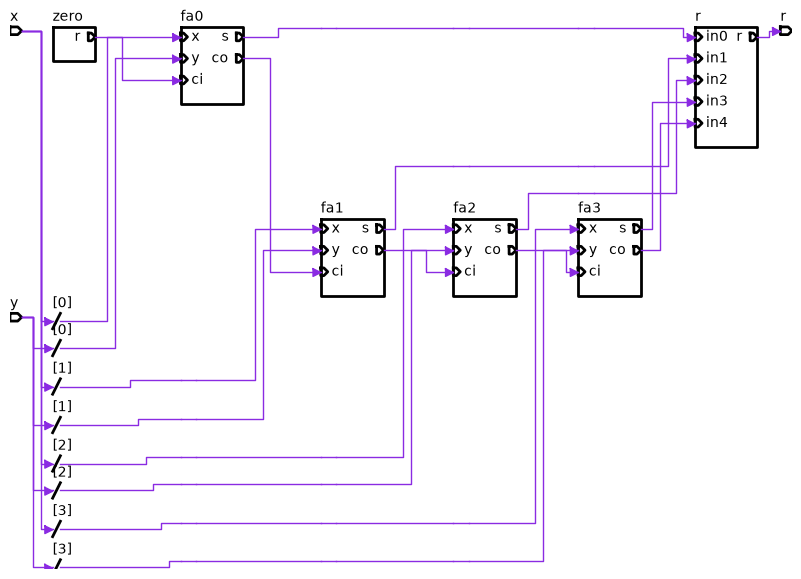

In [11]:
hw = py4hw.HWSystem()
x = hw.wire('a', 4)
y = hw.wire('b', 4)
r = hw.wire('r', 5)

fa = Adder4(hw, 'fa', x,y, r)
sch = py4hw.Schematic(fa)

sch.draw()

In [14]:
hw = py4hw.HWSystem()

x = hw.wire('x', 4)
y = hw.wire('y', 4)
r = hw.wire('r', 5)

py4hw.Sequence(hw, 'x', [0, 1, 3, 7, 15], x)
py4hw.Sequence(hw, 'y', [0, 1, 2, 4, 15], y)

Adder4(hw, 'Adder4', x, y, r)

wvf = py4hw.Waveform(hw, 'wvf', [x, y, r])

hw.getSimulator().clk(20)

wvf.draw_wavedrom()